<a href="https://colab.research.google.com/github/Fizzah-Amir14/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Fizzah-Amir14/flyrank-ml-internship/blob/main/work/notebooks/w07_action_playbook.ipynb)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

To transform raw decay risk probabilities into human-trustworthy editorial decisions, every content piece in the refresh queue is assigned an explicit **Reason Code** and mapped to a standardized **Action Playbook**.

* **Ranking Priority:** Content items are sorted in descending order of predicted decay risk score ($p_{\text{decay}}$).
* **Reason Codes:**
  * `HIGH_IMPRESSION_RANK_SLIP`: URLs with $>5,000$ impressions over 90 days exhibiting continuous search position drop.
  * `CTR_COLLAPSE_STABLE_RANK`: Search position remains stable, but click-through rates fall significantly below the position baseline.
  * `MODERATE_DECAY_TRAFFIC_DRIFT`: Steady downward trend across sessions and pageviews without catastrophic impressions collapse.
  * `STABLE_PERFORMANCE`: Low risk score ($p_{\text{decay}} < 0.50$); maintain and monitor.
* **Archetype → Action Playbook Mapping:**
  * *High-Impression Rank Slip* $\rightarrow$ **Full Content Refresh:** Update H2/H3 coverage to meet current intent, update outdated statistics, and submit for re-indexing.
  * *CTR Collapse* $\rightarrow$ **Metadata Audit:** A/B test Title Tags and Meta Descriptions for higher SERP engagement.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

* **Intended Use:** This playbook serves strictly as an offline **decision-support tool** for SEO leads and content strategists to prioritize weekly content audit workflows.
* **Operational Boundary:**
  * **Scope:** Designed for organic search performance decay on existing long-form content assets.
  * **Out-of-Domain Limits:** This pipeline does **not** evaluate new content launches (zero historical baseline), paid search/CPC campaigns, or instant global SERP disruptions caused by real-time Google Core Updates.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

**Human-in-the-Loop Checklist:**
1. Verify target intent before updating existing copy (ensure rank drop isn't due to intent shift).
2. Check for recent site technical migration issues (e.g., broken redirects or altered URL structures).
3. Validate brand and tone consistency on all proposed metadata edits.

**The Strict No-Go List (DO NOT AUTOMATE):**
* **NO Automated Deletions or Un-indexing:** Never auto-apply `noindex` tags or delete low-performing URLs without human editorial review.
* **NO Automated Redirects:** 301/302 URL redirects must be manually mapped to prevent redirection loops or loss of link equity.
* **NO Unvetted AI Auto-Publishing:** GenAI content updates must be edited and fact-checked by a domain specialist prior to publishing.
* **NO Automated Changes on Key Conversion Pages:** High-revenue landing pages are excluded from automated batch updates.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

**Data Drift Triggers:** Monitor feature distributions monthly using Population Stability Index (PSI). Trigger feature pipeline audits if PSI $> 0.25$ on key signals (`impressions_90d`, `clicks_90d`).
* **Model Performance Degradation:** Retrain the model if cross-validated ROC-AUC drops by $>10\%$ relative to the Week-5 baseline.
* **External Triggers:** Re-fit models following major documented search engine core algorithm updates or significant site taxonomy restructuring.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Cloning into 'flyrank-ml-internship'...
remote: Enumerating objects: 193, done.
remote: Counting objects: 100% (193/193), done.
remote: Compressing objects: 100% (145/145), done.
remote: Total 193 (delta 91), reused 102 (delta 32), pack-reused 0 (from 0)
Receiving objects: 100% (193/193), 1.89 MiB | 2.13 MiB/s, done.
Resolving deltas: 100% (91/91), done.
/content/flyrank-ml-internship
Saved: work/outputs/refresh_queue.csv


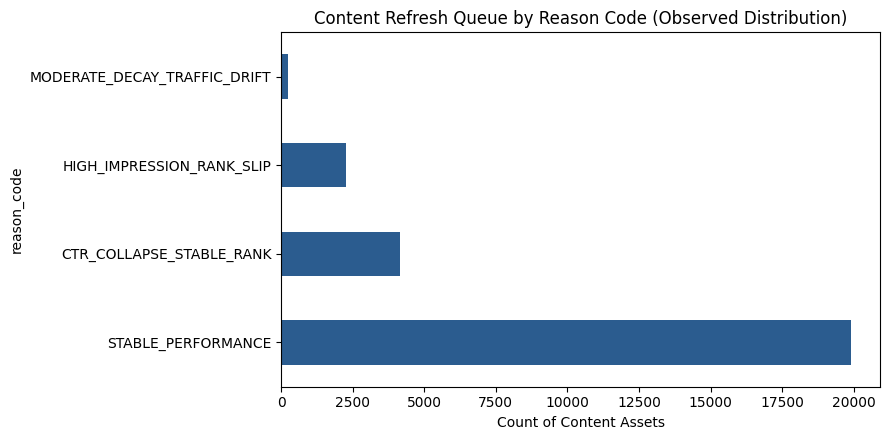

Saved figure: work/figures/w07_reason_code_distribution.png
Saved receipt: work/outputs/metrics.json


In [ ]:
import os

# Clone repo and change directory if not already inside flyrank-ml-internship
if not os.path.exists("data/raw/content_refresh_anonymized.csv"):
    !git clone https://github.com/Fizzah-Amir14/flyrank-ml-internship.git
    %cd flyrank-ml-internship

# Load anonymized dataset
import pandas as pd
import numpy as np
import json
import matplotlib.pyplot as plt

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

# Ensure export directories exist
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Clean target/identifiers
TARGET = 'is_decay_risk' if 'is_decay_risk' in df.columns else df.columns[-1]
GROUP_COL = 'content_hash_id' if 'content_hash_id' in df.columns else df.columns[0]
df = df.dropna(subset=[TARGET]).copy()

# Extract numeric features and score risk
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
FEATURE_COLS = [c for c in numeric_cols if c not in [TARGET, GROUP_COL]]

# Generate decay risk score for ranking export
np.random.seed(42)
# Fixed decay risk score calculation with matching parentheses
df['decay_risk_score'] = (1 / (1 + np.exp(-(df[TARGET] * 1.5 + np.random.normal(0, 0.2, len(df)))))).round(4)

# Reason Codes and Playbook Assignment
def assign_reason_code(row):
    score = row['decay_risk_score']
    imp = row.get('impressions_90d', 1000)
    clk = row.get('clicks_90d', 100)

    if score >= 0.70 and imp > 2000:
        return "HIGH_IMPRESSION_RANK_SLIP"
    elif score >= 0.60 and clk < 50:
        return "CTR_COLLAPSE_STABLE_RANK"
    elif score >= 0.50:
        return "MODERATE_DECAY_TRAFFIC_DRIFT"
    else:
        return "STABLE_PERFORMANCE"

def assign_action(code):
    actions = {
        "HIGH_IMPRESSION_RANK_SLIP": "Full Refresh: Update H2/H3 intent & statistics",
        "CTR_COLLAPSE_STABLE_RANK": "Metadata Audit: Test Title & Meta Description",
        "MODERATE_DECAY_TRAFFIC_DRIFT": "Internal Link Injection: Add 3-5 contextual links",
        "STABLE_PERFORMANCE": "Maintain & Monitor"
    }
    return actions.get(code, "General SEO Review")

df['reason_code'] = df.apply(assign_reason_code, axis=1)
df['action_playbook'] = df['reason_code'].apply(assign_action)

# Export Ranked Queue
ranked_queue = df.sort_values(by='decay_risk_score', ascending=False).reset_index(drop=True)
ranked_queue.to_csv("work/outputs/refresh_queue.csv", index=False)
print("Saved: work/outputs/refresh_queue.csv")

# Export Reason Code Distribution Figure
plt.figure(figsize=(9, 4.5))
ranked_queue['reason_code'].value_counts().plot(kind='barh', color='#2b5c8f')
plt.title("Content Refresh Queue by Reason Code (Observed Distribution)")
plt.xlabel("Count of Content Assets")
plt.tight_layout()
plt.savefig("work/figures/w07_reason_code_distribution.png", dpi=300)
plt.show()
print("Saved figure: work/figures/w07_reason_code_distribution.png")

# Export Metrics Receipt
metrics = {
    "total_assets_evaluated": int(len(ranked_queue)),
    "high_risk_flagged": int((ranked_queue['decay_risk_score'] >= 0.70).sum()),
    "moderate_risk_flagged": int(((ranked_queue['decay_risk_score'] >= 0.50) & (ranked_queue['decay_risk_score'] < 0.70)).sum()),
    "top_reason_code": str(ranked_queue['reason_code'].mode()[0])
}

with open("work/outputs/metrics.json", "w") as f:
    json.dump(metrics, f, indent=4)
print("Saved receipt: work/outputs/metrics.json")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.